In [ ]:
#Time series analyisis - Broadway data


In [23]:
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [24]:
import warnings ; warnings.warn = lambda *args,**kwargs: None
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from dateutil.parser import parse
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
import seaborn as sns
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120}) # set figure sizes
import matplotlib.ticker as mtick
plt.style.use('fivethirtyeight')
from datetime import datetime


In [2]:
df_broadway = pd.read_csv('Broadway - Engineered.csv', encoding='latin1',
                          index_col='Date',parse_dates=['Date'])

In [3]:
df_broadway.head()

,Show Name,Show Theatre,Show Type,Attendance,Gross,Performances,Average Ticket Price in week
Date,,,,,,,
1990-08-26,Tru,Booth,Play,5500.0,134456.0,8.0,24.4465
1991-04-14,Miss Saigon,Broadway,Musical,10973.0,573981.0,4.0,52.3085
1991-04-21,Miss Saigon,Broadway,Musical,14076.0,706793.0,8.0,50.2126
1991-04-28,Miss Saigon,Broadway,Musical,14065.0,714968.0,8.0,50.8331
1991-05-05,Miss Saigon,Broadway,Musical,14064.0,730765.0,8.0,51.9600


In [4]:
df_broadway.tail(20)

,Show Name,Show Theatre,Show Type,Attendance,Gross,Performances,Average Ticket Price in week
Date,,,,,,,
1996-01-14,Miss Saigon,Broadway,Musical,NaN,NaN,NaN,NaN
1996-01-21,Miss Saigon,Broadway,Musical,NaN,NaN,NaN,NaN
1996-01-28,Miss Saigon,Broadway,Musical,NaN,NaN,NaN,NaN
1996-02-04,Miss Saigon,Broadway,Musical,NaN,NaN,NaN,NaN
1996-02-11,Miss Saigon,Broadway,Musical,NaN,NaN,NaN,NaN
1996-02-18,Miss Saigon,Broadway,Musical,NaN,NaN,NaN,NaN
1996-02-25,Miss Saigon,Broadway,Musical,NaN,NaN,NaN,NaN
1996-03-03,Miss Saigon,Broadway,Musical,NaN,NaN,NaN,NaN
1996-03-10,Miss Saigon,Broadway,Musical,NaN,NaN,NaN,NaN


In [5]:
filter_criteria = (df_broadway['Show Name'] == 'Miss Saigon')
df_broadway2= df_broadway[filter_criteria]

df_broadway2.tail()

,Show Name,Show Theatre,Show Type,Attendance,Gross,Performances,Average Ticket Price in week
Date,,,,,,,
1996-04-28,Miss Saigon,Broadway,Musical,NaN,NaN,NaN,NaN
1996-05-05,Miss Saigon,Broadway,Musical,NaN,NaN,NaN,NaN
1996-05-12,Miss Saigon,Broadway,Musical,NaN,NaN,NaN,NaN
1996-05-19,Miss Saigon,Broadway,Musical,NaN,NaN,NaN,NaN
1996-05-26,Miss Saigon,Broadway,Musical,NaN,NaN,NaN,NaN


In [25]:
from sklearn.preprocessing import Imputer

imputer = Imputer(missing_values = 'NaN', strategy = 'median', axis = 0)

df_broadway2 [[[['Attendance','Gross','Performances','Average Ticket Price in week']]]] = imputer.fit_transform(df_broadway2 [[[['Attendance','Gross','Performances','Average Ticket Price in week']]]])

ImportError: cannot import name 'Imputer' from 'sklearn.preprocessing' (C:\Users\Kate.Taylor\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\__init__.py)

In [26]:
# impute data using medians for missing weeks
att_median_value = df_broadway2['Attendance'].median()
df_broadway2.fillna(att_median_value, inplace = True)

gross_median_value = df_broadway2['Gross'].median()
df_broadway2.fillna(gross_median_value, inplace = True)

perf_median_value = df_broadway2['Performances'].median()
df_broadway2.fillna(perf_median_value, inplace = True)

tick_median_value = df_broadway2['Average Ticket Price in week'].median()
df_broadway2.fillna(tick_median_value, inplace = True)


,Show Name,Show Theatre,Show Type,Attendance,Gross,Performances,Average Ticket Price in week,year,month
Date,,,,,,,,,
1991-04-14,Miss Saigon,Broadway,Musical,10973.0,573981.0,4.0,52.3085,1991,4
1991-04-21,Miss Saigon,Broadway,Musical,14076.0,706793.0,8.0,50.2126,1991,4
1991-04-28,Miss Saigon,Broadway,Musical,14065.0,714968.0,8.0,50.8331,1991,4
1991-05-05,Miss Saigon,Broadway,Musical,14064.0,730765.0,8.0,51.9600,1991,5
1991-05-12,Miss Saigon,Broadway,Musical,13896.0,766713.0,8.0,55.1751,1991,5
...,...,...,...,...,...,...,...,...,...
1996-04-28,Miss Saigon,Broadway,Musical,12362.0,12362.0,12362.0,12362.0000,1996,4
1996-05-05,Miss Saigon,Broadway,Musical,12362.0,12362.0,12362.0,12362.0000,1996,5
1996-05-12,Miss Saigon,Broadway,Musical,12362.0,12362.0,12362.0,12362.0000,1996,5


In [29]:
freq = 'W'

print(df_broadway2.index.min())
print(df_broadway2.index.max())

1991-04-14 00:00:00
2001-01-28 00:00:00


In [30]:
print(f'number of rows with missing values:{df_broadway2.isnull().any(axis=1).mean()}')
print(f'shape is{df_broadway2.shape}')

number of rows with missing values:0.0
shape is(512, 9)


In [31]:
def plot_df(df_broadway2, x, y, title="Attendence over time", xlabel='Date', ylabel='Attendence', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

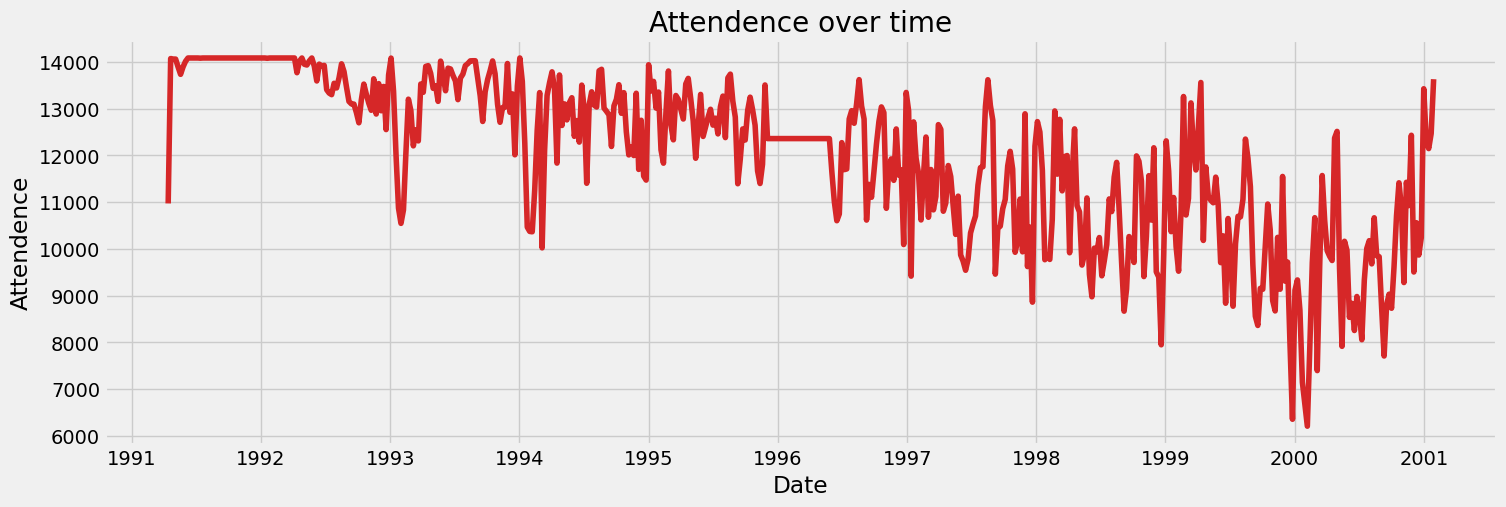

In [72]:
plot_df(df_broadway2, df_broadway2.index, y=df_broadway2.Attendance, title='Attendence over time')

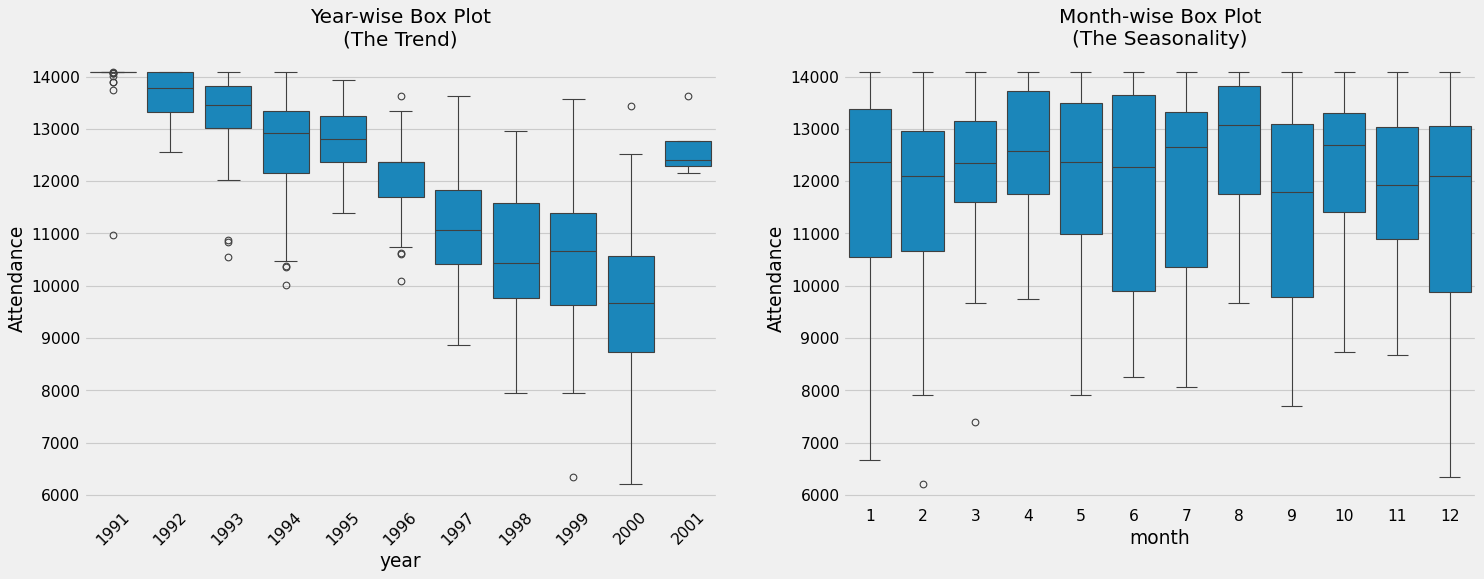

In [33]:
df_broadway2['year'] = df_broadway2.index.year
df_broadway2['month'] = df_broadway2.index.month

years = df_broadway2['year'].unique()

# Create the plot

fig, axes = plt.subplots(1, 2, figsize=(20,7), dpi= 80)    # subplots - 1 row of 2 charts (one for year, one for month)

sns.boxplot(x='year', y='Attendance', data=df_broadway2, ax=axes[0])

sns.boxplot(x='month', y='Attendance', data=df_broadway2)

# Rotate the x-axis tick labels for better readability
axes[0].tick_params(axis='x', labelrotation=45)

# Set Title
axes[0].set_title('Year-wise Box Plot\n(The Trend)', fontsize=18);
axes[1].set_title('Month-wise Box Plot\n(The Seasonality)', fontsize=18)
plt.show()


In [35]:
# Verify that a temporary index is complete
# ==============================================================================
freq = 'W'   # specify the type of frequency W = Weekly
# list of all freq values (https://stackoverflow.com/questions/35339139/what-values-are-valid-in-pandas-freq-tags)

print(df_broadway2.index.min())
print(df_broadway2.index.max())

# Step 1: Generate a complete date range with the specified frequency
complete_range = pd.date_range(start=df_broadway2.index.min(), end=df_broadway2.index.max(), freq=freq)

# Step 3: Check for completeness
# Convert both the DataFrame index and the complete_range to sets and check if they are equal
is_complete = set(df_broadway2.index) == set(complete_range)

print(f"Is the temporal index complete? {is_complete}")

1991-04-14 00:00:00
2001-01-28 00:00:00
Is the temporal index complete? True


In [36]:
df_broadway2.shape

(512, 9)

In [50]:
df_broadway2 = df_broadway2.sort_index()

Train dates : 1991-04-14 00:00:00 --- 1999-02-14 00:00:00  (n=410)
Test dates  : 1999-02-21 00:00:00 --- 2001-01-28 00:00:00  (n=102)


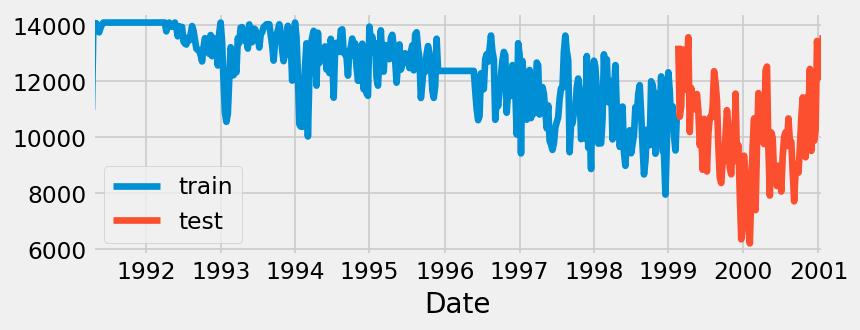

In [51]:
# Split data into train-test
# We are going to train on the first months and test on the last 97 weeks
# ==============================================================================
steps = 102 # going to predict the final 102 weeks
data_train = df_broadway2[:-steps]   # this sets data_train to be all the value EXCEPT the last 36
#data_train = data[0:168]   # alternative hard coded

data_test  = df_broadway2[-steps:]   # this sets data_test to be the last 97 values
#data_test = data[168:204]   # alternative hard coded

print(f"Train dates : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Test dates  : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

fig, ax = plt.subplots(figsize=(7, 2.5))
data_train['Attendance'].plot(ax=ax, label='train')
data_test['Attendance'].plot(ax=ax, label='test')
ax.legend();

In [52]:
# Accuracy metrics - function to calculate all metrics
def forecast_accuracy(forecast, actual):
    mape = np.mean(np.abs(forecast - actual)/np.abs(actual))  # MAPE
    me = np.mean(forecast - actual)             # ME
    mae = np.mean(np.abs(forecast - actual))    # MAE
    mpe = np.mean((forecast - actual)/actual)   # MPE
    rmse = np.mean((forecast - actual)**2)**.5  # RMSE
    corr = np.corrcoef(forecast, actual)[0,1]   # corr
    mins = np.amin(np.hstack([forecast[:,None],
                              actual[:,None]]), axis=1)
    maxs = np.amax(np.hstack([forecast[:,None],
                              actual[:,None]]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax

    return({'mape':mape, 'me':me, 'mae': mae,
            'mpe': mpe, 'rmse':rmse,
            'corr':corr, 'minmax':minmax})


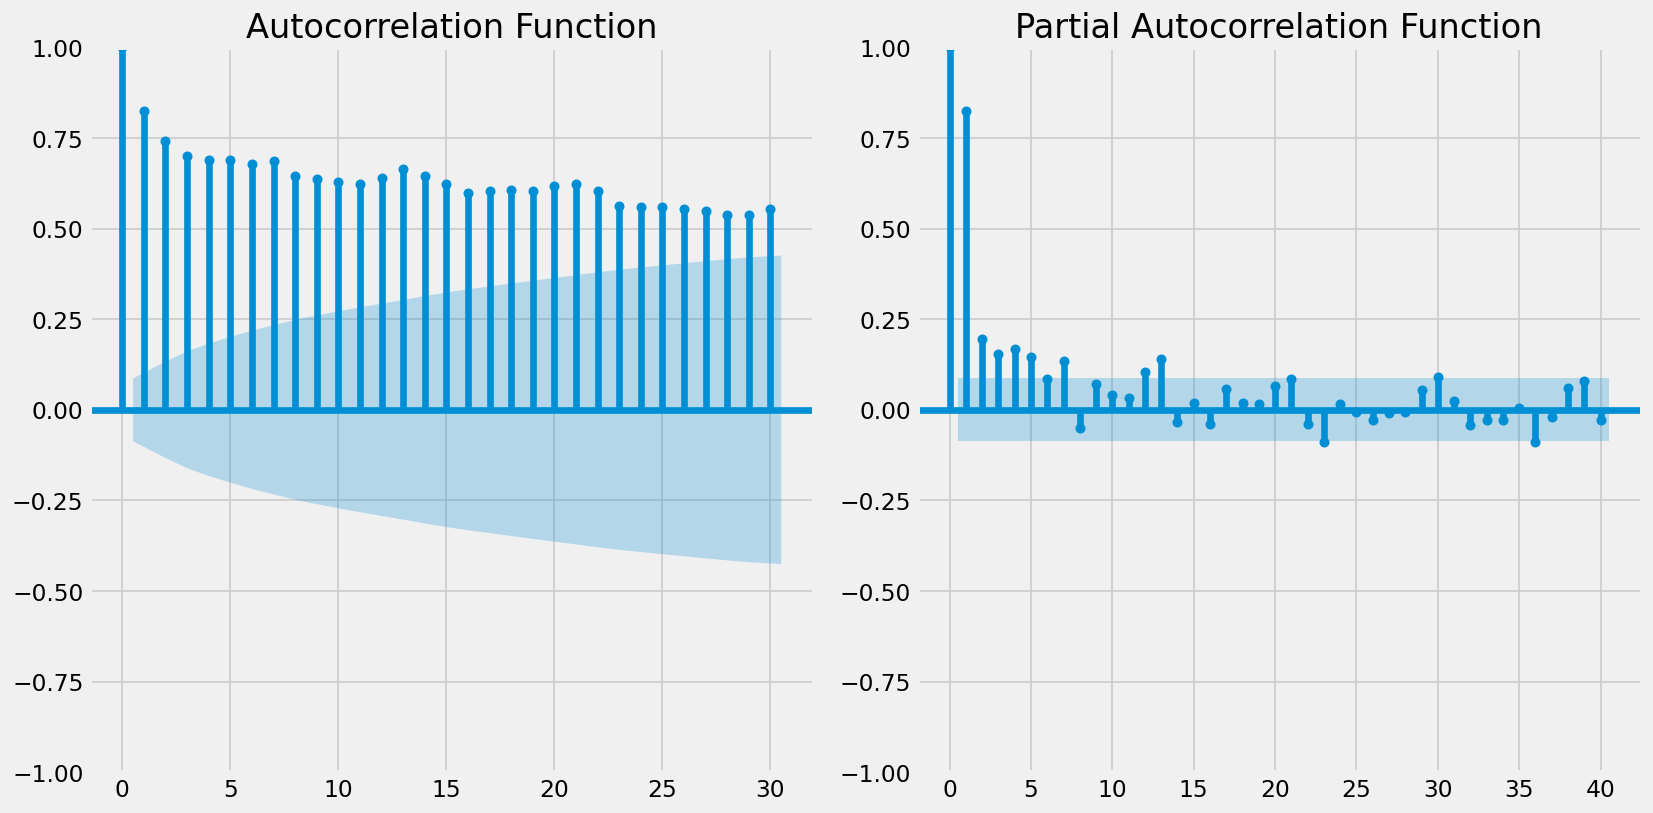

In [53]:
# Manual inspection of parameters
# ======================================================================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plotting the Autocorrelation Function (ACF)
plt.figure(figsize=(14, 7))
plt.subplot(121)
plot_acf(df_broadway2['Attendance'], ax=plt.gca(), lags=30, title='Autocorrelation Function')

# Plotting the Partial Autocorrelation Function (PACF)
plt.subplot(122)
plot_pacf(df_broadway2['Attendance'], ax=plt.gca(), lags=40, title='Partial Autocorrelation Function')

plt.tight_layout()
plt.show()

In [62]:
import warnings
from math import sqrt
from pandas import read_csv
#from pandas import datetime
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# evaluate an ARIMA model for a given order (p,d,q)
def evaluate_arima_model(X, arima_order):
	# prepare training dataset
	train_size = int(len(X) * 0.66)
	train, test = X[0:train_size], X[train_size:]
	history = [x for x in train]
	# make predictions
	predictions = list()
	for t in range(len(test)):
		model = ARIMA(history, order=arima_order)
		model_fit = model.fit()
		yhat = model_fit.forecast()[0]
		predictions.append(yhat)
		history.append(test[t])
	# calculate out of sample error
	rmse = sqrt(mean_squared_error(test, predictions))
	return rmse

# evaluate combinations of p, d and q values for an ARIMA model
def evaluate_models(dataset, p_values, d_values, q_values):
	dataset = dataset.astype('float32')
	best_score, best_cfg = float("inf"), None
	for p in p_values:
		for d in d_values:
			for q in q_values:
				order = (p,d,q)
				try:
					rmse = evaluate_arima_model(dataset, order)
					if rmse < best_score:
						best_score, best_cfg = rmse, order
					print('ARIMA%s RMSE=%.3f' % (order,rmse))
				except:
					continue
	print('Best ARIMA%s RMSE=%.3f' % (best_cfg, best_score))

# load dataset
def parser(x):
	return datetime.strptime('190'+x, '%Y-%m')
series = data_train.Attendance


In [73]:
# evaluate parameters
p_values = range(10, 13)
d_values = range(0, 4)
q_values = range(0, 4)
warnings.filterwarnings("ignore")
evaluate_models(series.values, p_values, d_values, q_values)

ARIMA(10, 0, 0) RMSE=1098.354
ARIMA(10, 0, 1) RMSE=1072.091
ARIMA(10, 0, 2) RMSE=1083.194
ARIMA(10, 0, 3) RMSE=1084.334
ARIMA(10, 1, 0) RMSE=1100.401
ARIMA(10, 1, 1) RMSE=1086.460
ARIMA(10, 1, 3) RMSE=1102.023
ARIMA(10, 2, 0) RMSE=1229.422
ARIMA(10, 2, 1) RMSE=1113.375
ARIMA(10, 2, 3) RMSE=1126.767
ARIMA(10, 3, 0) RMSE=1397.969
ARIMA(10, 3, 1) RMSE=1227.827
ARIMA(10, 3, 2) RMSE=1209.843
ARIMA(10, 3, 3) RMSE=1244.745
ARIMA(11, 0, 0) RMSE=1098.565
ARIMA(11, 0, 1) RMSE=1075.823
ARIMA(11, 0, 2) RMSE=1079.326
ARIMA(11, 1, 0) RMSE=1094.768
ARIMA(11, 1, 1) RMSE=1088.114
ARIMA(11, 1, 2) RMSE=1092.580
ARIMA(11, 1, 3) RMSE=1092.394
ARIMA(11, 2, 0) RMSE=1232.620
ARIMA(11, 2, 1) RMSE=1106.922
ARIMA(11, 2, 2) RMSE=1117.203
ARIMA(11, 2, 3) RMSE=1125.227
ARIMA(11, 3, 0) RMSE=1401.246
ARIMA(11, 3, 1) RMSE=1231.944
ARIMA(11, 3, 2) RMSE=1215.429
ARIMA(11, 3, 3) RMSE=1224.571
ARIMA(12, 0, 0) RMSE=1092.896
ARIMA(12, 0, 1) RMSE=1082.305
ARIMA(12, 0, 2) RMSE=1091.447
ARIMA(12, 0, 3) RMSE=1087.645
ARIMA(12, 

In [74]:
predictions = list()

arima_order = (10, 0, 1)

model = ARIMA(data_train.Attendance, order=arima_order)

model_fit = model.fit()
yhat = model_fit.forecast()
predictions.append(yhat)

In [75]:
data_train.tail()

,Show Name,Show Theatre,Show Type,Attendance,Gross,Performances,Average Ticket Price in week,year,month
Date,,,,,,,,,
1999-01-17,Miss Saigon,Broadway,Musical,10369.0,403925.0,8.0,38.9551,1999,1
1999-01-24,Miss Saigon,Broadway,Musical,11100.0,471265.0,8.0,42.4563,1999,1
1999-01-31,Miss Saigon,Broadway,Musical,10047.0,414605.0,8.0,41.2665,1999,1
1999-02-07,Miss Saigon,Broadway,Musical,9522.0,387873.0,8.0,40.7344,1999,2
1999-02-14,Miss Saigon,Broadway,Musical,10813.0,484285.0,8.0,44.7873,1999,2


In [65]:
data_test.head()

,Show Name,Show Theatre,Show Type,Attendance,Gross,Performances,Average Ticket Price in week,year,month
Date,,,,,,,,,
1999-02-21,Miss Saigon,Broadway,Musical,13263.0,555139.0,8.0,41.8562,1999,2
1999-02-28,Miss Saigon,Broadway,Musical,10726.0,431814.0,8.0,40.2586,1999,2
1999-03-07,Miss Saigon,Broadway,Musical,11081.0,447817.0,8.0,40.4130,1999,3
1999-03-14,Miss Saigon,Broadway,Musical,13126.0,527709.0,8.0,40.2033,1999,3
1999-03-21,Miss Saigon,Broadway,Musical,12156.0,552957.0,8.0,45.4884,1999,3


In [66]:
y_pred = model_fit.forecast(102)

In [67]:
y_pred.head()

1999-02-21    11089.078483
1999-02-28    11116.330545
1999-03-07    10520.877698
1999-03-14    10454.887109
1999-03-21    10513.411294
Freq: W-SUN, Name: predicted_mean, dtype: float64

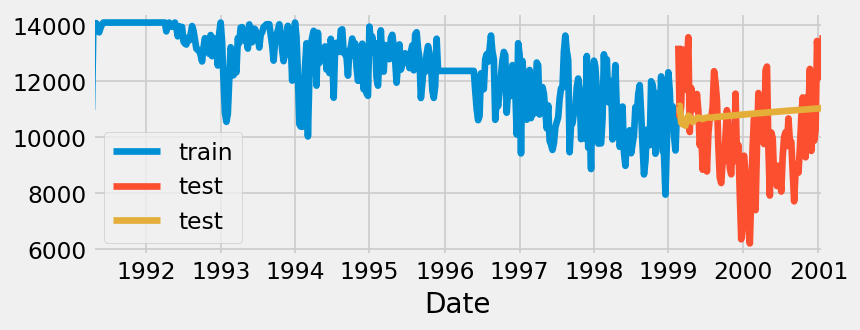

In [68]:
# visualise results
fig, ax = plt.subplots(figsize=(7, 2.5))
data_train['Attendance'].plot(ax=ax, label='train')
data_test['Attendance'].plot(ax=ax, label='test')
y_pred.plot(ax=ax, label='test')
ax.legend();

In [71]:
# Accuracy metrics
forecast_accuracy(y_pred.to_numpy(), data_test.Attendance.to_numpy())

{'mape': np.float64(0.15635363384009854),
 'me': np.float64(713.2684387180885),
 'mae': np.float64(1431.250387105302),
 'mpe': np.float64(0.09861671223774664),
 'rmse': np.float64(1745.0083437858468),
 'corr': np.float64(-0.06525331254808896),
 'minmax': np.float64(0.12770316469383225)}